# Baseline: Ensemble (Voting + Stacking)

## 0. Setup

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.config import TRAIN_CSV, TEST_CSV, SAMPLE_SUBMIT_CSV, SEED, N_FOLDS, TARGET_COL, ID_COL
from src.utils import seed_everything
from src.features import compute_train_stats, build_pipeline
from src.evaluation import cross_validate, calc_metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from src.evaluation import cross_validate_oof
seed_everything(SEED)

with open("../../configs/default.yaml") as f:
    config = yaml.safe_load(f)

print("Feature version:", config["feature_version"])

Feature version: v1


## 1. Data Loading

In [2]:
train = pd.read_csv(TRAIN_CSV, index_col=0)
test = pd.read_csv(TEST_CSV, index_col=0)

y = train[TARGET_COL]
train = train.drop(columns=[TARGET_COL])

train_stats = compute_train_stats(train)

X_train = build_pipeline(train, version=config["feature_version"], train_stats=train_stats)
X_test = build_pipeline(test, version=config["feature_version"], train_stats=train_stats)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
X_train.head()

X_train: (445, 14), X_test: (446, 14)


,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S,family_size,is_alone,log_fare,fare_per_person,pclass_sex
id,,,,,,,,,,,,,,
3,1,1,35.0,1,0,53.1000,0,0,1,2,0,3.990834,26.5500,11
4,3,0,35.0,0,0,8.0500,0,0,1,1,1,2.202765,8.0500,30
7,3,0,2.0,3,1,21.0750,0,0,1,5,0,3.094446,4.2150,30
9,2,1,14.0,1,0,30.0708,1,0,0,2,0,3.436268,15.0354,21
11,1,1,58.0,0,0,26.5500,0,0,1,1,1,3.316003,26.5500,11


## 2. Feature Engineering

In [3]:
print(f'Features: {list(X_train.columns)}')

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S', 'family_size', 'is_alone', 'log_fare', 'fare_per_person', 'pclass_sex']


## 3. Individual Model CV (for comparison)

In [4]:
def make_logreg():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=config["logistic_regression"]["C"],
            penalty=config["logistic_regression"]["penalty"],
            solver=config["logistic_regression"]["solver"],
            max_iter=config["logistic_regression"]["max_iter"],
            random_state=SEED,
        ))
    ])

def make_rf():
    return RandomForestClassifier(**config["random_forest"])

def make_xgb():
    return XGBClassifier(**config["xgboost"])

def make_lgbm():
    return LGBMClassifier(**config["lightgbm"])

results = {}
for name, fn in [("LogReg", make_logreg), ("RF", make_rf), ("XGB", make_xgb), ("LGBM", make_lgbm)]:
    _, mean_m = cross_validate(fn, X_train, y)
    results[name] = mean_m
    auc_str = f", auc={mean_m['auc']:.4f}" if "auc" in mean_m else ""
    print(f"{name}: acc={mean_m['accuracy']:.4f}, f1={mean_m['f1']:.4f}{auc_str}")

LogReg: acc=0.8000, f1=0.7410, auc=0.8536


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

RF: acc=0.8045, f1=0.7510, auc=0.8603


XGB: acc=0.8000, f1=0.7389, auc=0.8561


LGBM: acc=0.7865, f1=0.7290, auc=0.8429


## 4a. Soft Voting Ensemble

In [5]:
def make_voting():
    estimators = [
        ("logreg", make_logreg()),
        ("rf", make_rf()),
        ("xgb", make_xgb()),
        ("lgbm", make_lgbm()),
    ]
    return VotingClassifier(estimators=estimators, voting="soft")

fold_metrics_voting, mean_metrics_voting = cross_validate(make_voting, X_train, y)
results["Voting"] = mean_metrics_voting
print("=== Soft Voting ===")
for k, v in mean_metrics_voting.items():
    print(f"  {k}: {v:.4f}")

/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== Soft Voting ===
  accuracy: 0.8000
  f1: 0.7426
  logloss: 0.4413
  auc: 0.8639


## 4b. Stacking Ensemble

In [6]:
def make_stacking():
    estimators = [
        ("logreg", make_logreg()),
        ("rf", make_rf()),
        ("xgb", make_xgb()),
        ("lgbm", make_lgbm()),
    ]
    return StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
        cv=5,
    )

fold_metrics_stacking, mean_metrics_stacking = cross_validate(make_stacking, X_train, y)
results["Stacking"] = mean_metrics_stacking
print("=== Stacking ===")
for k, v in mean_metrics_stacking.items():
    print(f"  {k}: {v:.4f}")

/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

=== Stacking ===
  accuracy: 0.8022
  f1: 0.7448
  logloss: 0.4446
  auc: 0.8636


## 5. Comparison Table

=== All Models Comparison ===


,accuracy,f1,logloss,auc
Voting,0.800000,0.742561,0.441299,0.863885
Stacking,0.802247,0.744844,0.444594,0.863580
RF,0.804494,0.751026,0.455740,0.860348
XGB,0.800000,0.738923,0.468649,0.856147
LogReg,0.800000,0.741026,0.456558,0.853625
LGBM,0.786517,0.729014,0.538265,0.842870


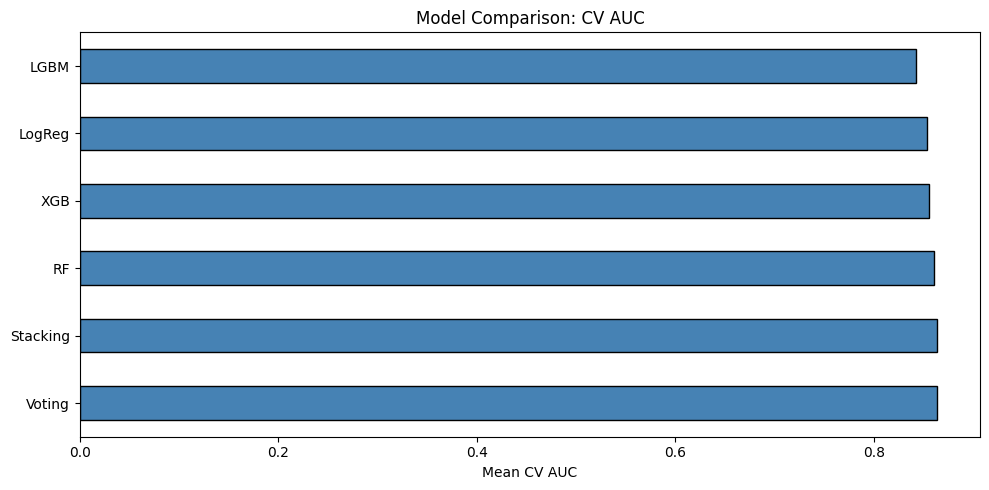

In [7]:
comparison_df = pd.DataFrame(results).T.sort_values("auc" if "auc" in list(results.values())[0] else "accuracy", ascending=False)
print("=== All Models Comparison ===")
display(comparison_df)

sort_col = "auc" if "auc" in comparison_df.columns else "accuracy"
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df[sort_col].plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel(f"Mean CV {sort_col.upper()}")
ax.set_title(f"Model Comparison: CV {sort_col.upper()}")
plt.tight_layout()
plt.show()

## 6. Train Best Model & Predict

In [8]:
# Select best model based on CV AUC (or accuracy)
best_name = comparison_df.index[0]
print(f"Best model: {best_name}")

model_map = {
    "LogReg": make_logreg,
    "RF": make_rf,
    "XGB": make_xgb,
    "LGBM": make_lgbm,
    "Voting": make_voting,
    "Stacking": make_stacking,
}

final_model = model_map[best_name]()
final_model.fit(X_train, y)

y_pred_proba = final_model.predict_proba(X_test)[:, 1]
print(f"Predicted survival probability: mean={y_pred_proba.mean():.3f}, std={y_pred_proba.std():.3f}")

Best model: Voting


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Predicted survival probability: mean=0.393, std=0.316


## 7. Submission

In [9]:
sample_submit = pd.read_csv(SAMPLE_SUBMIT_CSV, index_col=0, header=None)
sample_submit[1] = final_model.predict_proba(X_test)[:, 1]
sample_submit.to_csv("submit.csv", header=None)

print(f"Submission shape: {sample_submit.shape}")
print(f"Prediction stats: mean={sample_submit[1].mean():.3f}, std={sample_submit[1].std():.3f}")
sample_submit.head()

Submission shape: (446, 1)
Prediction stats: mean=0.393, std=0.317


,1
0,
0,0.114815
1,0.953698
2,0.548914
5,0.167477
6,0.186976
